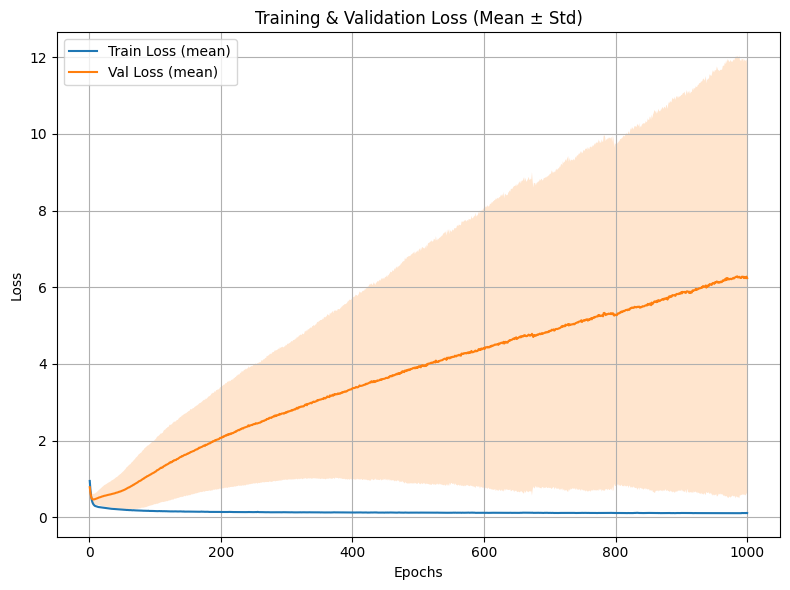

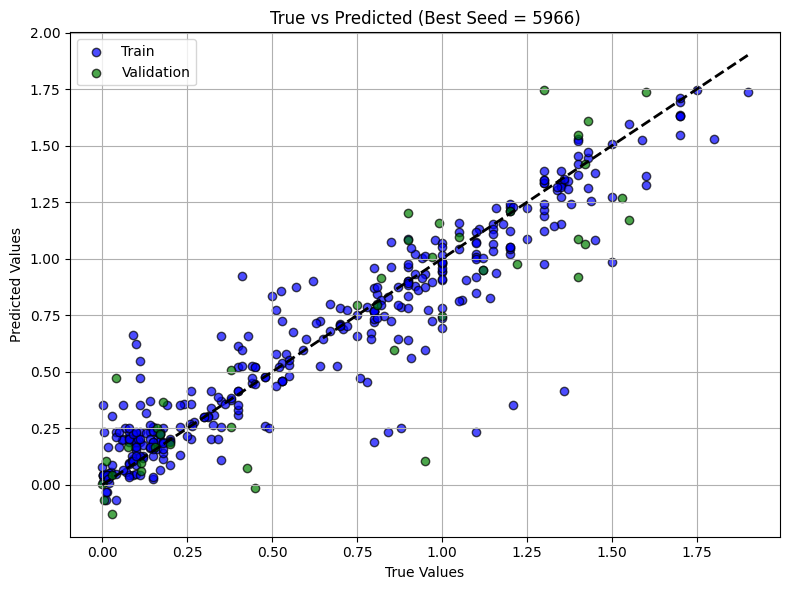

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import random
import re

# Set reproducibility seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Load and process dataset
df = pd.read_csv("composition_stoichiometric_cleaned.csv")
df["Temperature"] = df["Temperature "].apply(lambda x: float(re.sub(r"[^\d.]", "", str(x))))
element_cols = df.columns[2:-1]
X = pd.DataFrame({
    "Composition": list(df[element_cols].values),
    "Temperature": df["Temperature"].values
})
y = df["Figure of Merit"].values.reshape(-1, 1)

X_array = np.hstack([
    np.vstack(X["Composition"].values),
    X["Temperature"].values.reshape(-1, 1)
])

# Normalize features and target
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_array)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)
# X_scaled = X_array
# y_scaled = y

# Define DNN model
class FOMRegressor(nn.Module):
    def __init__(self, input_dim):
        super(FOMRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128,1),
        )

    def forward(self, x):
        return self.model(x)

# Prepare dataset once (constant for all seeds)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)
full_dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_train_losses = []
all_val_losses = []
best_seed = None
best_loss = float("inf")
with open("seeds_used.txt") as f:
    seeds = [int(line.strip()) for line in f]
all_models_info = []

all_train_losses_dict = {}
all_val_losses_dict = {}

for seed in seeds:
    set_seed(seed)
    train_dataset, val_dataset = random_split(
        full_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(seed)
    )
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)

    model = FOMRegressor(X_tensor.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    for epoch in range(1000):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_loss += criterion(preds, yb).item()
        val_losses.append(val_loss / len(val_loader))

    # Save losses for this seed
    all_train_losses_dict[seed] = train_losses
    all_val_losses_dict[seed] = val_losses
        # Save all seeds in one compressed file

    final_val_loss = val_losses[-1]
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

    if final_val_loss < best_loss:
        best_loss = final_val_loss
        best_seed = seed
        best_model = model
        best_train_loader = train_loader
        best_val_loader = val_loader
print(f"\n Best seed: {best_seed} with Validation Loss = {best_loss:.4f}")
np.savez_compressed("all_seed_losses_DNN.npz", train_losses=all_train_losses_dict,
                    val_losses=all_val_losses_dict)
# Plot average ± std loss curves
mean_train = np.mean(all_train_losses, axis=0)
std_train = np.std(all_train_losses, axis=0)
mean_val = np.mean(all_val_losses, axis=0)
std_val = np.std(all_val_losses, axis=0)

epochs = range(1, 1001)
plt.figure(figsize=(8,6))
plt.plot(epochs, mean_train, label="Train Loss (mean)")
plt.fill_between(epochs, mean_train - std_train, mean_train + std_train, alpha=0.2)
plt.plot(epochs, mean_val, label="Val Loss (mean)")
plt.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Mean ± Std)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_mean_std_curve_dnn.png")

# True vs Predicted for best seed
best_model.eval()
train_preds, train_trues, val_preds, val_trues = [], [], [], []

with torch.no_grad():
    for xb, yb in best_val_loader:
        xb = xb.to(device)
        output = best_model(xb)
        val_preds.extend(output.cpu().numpy())
        val_trues.extend(yb.numpy())

    for xb, yb in best_train_loader:
        xb = xb.to(device)
        output = best_model(xb)
        train_preds.extend(output.cpu().numpy())
        train_trues.extend(yb.numpy())

# Final plot

# Optional: inverse transform if needed
train_preds = scaler_y.inverse_transform(train_preds)
train_trues = scaler_y.inverse_transform(train_trues)
val_preds = scaler_y.inverse_transform(val_preds)
val_trues = scaler_y.inverse_transform(val_trues)

plt.figure(figsize=(8,6))
plt.scatter(train_trues, train_preds, alpha=0.7, label='Train', color='blue', edgecolor='k')
plt.scatter(val_trues, val_preds, alpha=0.7, label='Validation', color='green', edgecolor='k')
all_vals = np.concatenate([train_trues, val_trues])
plt.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()], 'k--', lw=2)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"True vs Predicted (Best Seed = {best_seed})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("true_vs_predicted_best_seed_dnn.png")


 Best seed: 5966 with Validation Loss = 0.2828


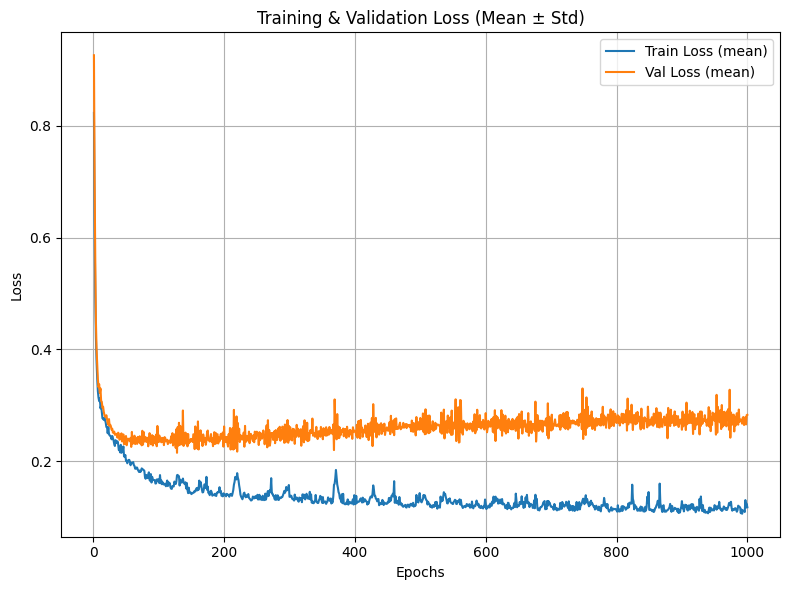

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import random
import re

# Set reproducibility seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Load and process dataset
df = pd.read_csv("composition_stoichiometric_cleaned.csv")
df["Temperature"] = df["Temperature "].apply(lambda x: float(re.sub(r"[^\d.]", "", str(x))))
element_cols = df.columns[2:-1]
X = pd.DataFrame({
    "Composition": list(df[element_cols].values),
    "Temperature": df["Temperature"].values
})
y = df["Figure of Merit"].values.reshape(-1, 1)

X_array = np.hstack([
    np.vstack(X["Composition"].values),
    X["Temperature"].values.reshape(-1, 1)
])

# Normalize features and target
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_array)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)
# X_scaled = X_array
# y_scaled = y

# Define DNN model
class FOMRegressor(nn.Module):
    def __init__(self, input_dim):
        super(FOMRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128,1),
        )

    def forward(self, x):
        return self.model(x)

# Prepare dataset once (constant for all seeds)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)
full_dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_train_losses = []
all_val_losses = []
best_seed = None
best_loss = float("inf")
# with open("seeds_used.txt") as f:
#     seeds = [int(line.strip()) for line in f]
all_models_info = []

all_train_losses_dict = {}
all_val_losses_dict = {}
seed = 5966
# for seed in seeds:
set_seed(seed)
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

model = FOMRegressor(X_tensor.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

train_losses = []
val_losses = []

for epoch in range(1000):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            val_loss += criterion(preds, yb).item()
    val_losses.append(val_loss / len(val_loader))

# Save losses for this seed
all_train_losses_dict[seed] = train_losses
all_val_losses_dict[seed] = val_losses
    # Save all seeds in one compressed file

final_val_loss = val_losses[-1]
all_train_losses.append(train_losses)
all_val_losses.append(val_losses)

if final_val_loss < best_loss:
    best_loss = final_val_loss
    best_seed = seed
    best_model = model
    best_train_loader = train_loader
    best_val_loader = val_loader
print(f"\n Best seed: {best_seed} with Validation Loss = {best_loss:.4f}")
np.savez_compressed("all_seed_losses_DNN.npz", train_losses=all_train_losses_dict,
                    val_losses=all_val_losses_dict)
# Plot average ± std loss curves
mean_train = np.mean(all_train_losses, axis=0)
std_train = np.std(all_train_losses, axis=0)
mean_val = np.mean(all_val_losses, axis=0)
std_val = np.std(all_val_losses, axis=0)

epochs = range(1, 1001)
plt.figure(figsize=(8,6))
plt.plot(epochs, mean_train, label="Train Loss (mean)")
plt.fill_between(epochs, mean_train - std_train, mean_train + std_train, alpha=0.2)
plt.plot(epochs, mean_val, label="Val Loss (mean)")
plt.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Mean ± Std)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_mean_std_curve_dnn.png")

# True vs Predicted for best seed
best_model.eval()
train_preds, train_trues, val_preds, val_trues = [], [], [], []

with torch.no_grad():
    for xb, yb in best_val_loader:
        xb = xb.to(device)
        output = best_model(xb)
        val_preds.extend(output.cpu().numpy())
        val_trues.extend(yb.numpy())

    for xb, yb in best_train_loader:
        xb = xb.to(device)
        output = best_model(xb)
        train_preds.extend(output.cpu().numpy())
        train_trues.extend(yb.numpy())

# Final plot

# Optional: inverse transform if needed
train_preds = scaler_y.inverse_transform(train_preds)
train_trues = scaler_y.inverse_transform(train_trues)
val_preds = scaler_y.inverse_transform(val_preds)
val_trues = scaler_y.inverse_transform(val_trues)



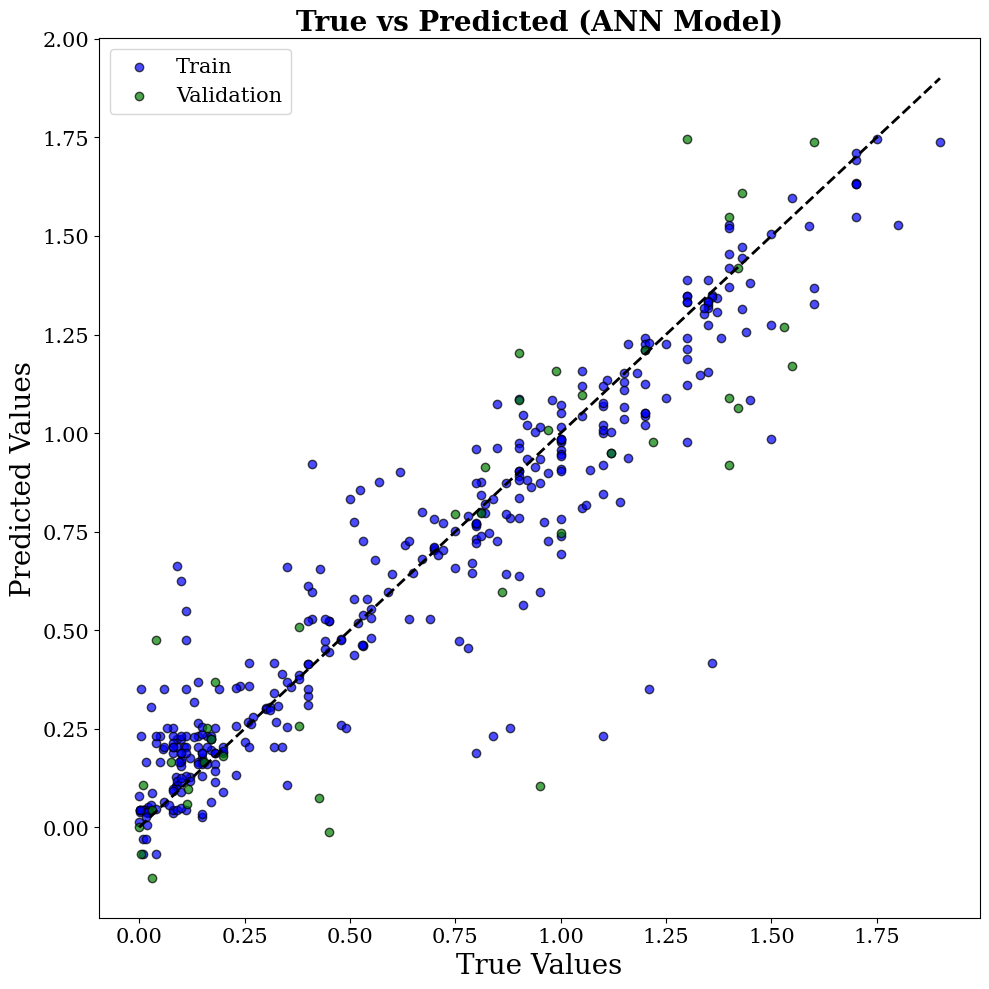

In [ ]:
plt.figure(figsize=(10,10))
plt.rcParams['font.family'] = 'serif'  # or 'sans-serif', 'monospace', 'cursive', 'fantasy'
plt.rcParams['font.serif'] = ['DejaVu Serif'] # Specify a particular font within the family
plt.rc('axes', titlesize=20) # Sets the font size for axes titles
plt.rc('axes', labelsize=20) # Sets the font size for axes labels
plt.rc('xtick', labelsize=15) # Sets the font size for x-axis tick labels
plt.rc('ytick', labelsize=15) # Sets the font size for y-axis tick labels
plt.rc('legend', fontsize=15) # Sets the font size for the legend
plt.scatter(train_trues, train_preds, alpha=0.7, label='Train', color='blue', edgecolor='k')
plt.scatter(val_trues, val_preds, alpha=0.7, label='Validation', color='green', edgecolor='k')
all_vals = np.concatenate([train_trues, val_trues])
plt.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()], 'k--', lw=2)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"True vs Predicted (ANN Model)",fontweight='bold')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig("true_vs_predicted_best_seed_dnn.png")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Convert to NumPy for sklearn
# train_preds_np = train_preds.numpy()
# train_trues_np = train_trues.numpy()
# val_preds_np = val_preds.numpy()
# val_trues_np = val_trues.numpy()

# Compute metrics
metrics = {
    "MSE": {
        "Train": mean_squared_error(train_trues, train_preds),
        "Validation": mean_squared_error(val_trues, val_preds)
    },
    "MAE": {
        "Train": mean_absolute_error(train_trues, train_preds),
        "Validation": mean_absolute_error(val_trues, val_preds)
    },
    "R²": {
        "Train": r2_score(train_trues, train_preds),
        "Validation": r2_score(val_trues, val_preds)
    }
}

# Print metrics in a table-like format
print("\nPerformance Metrics:")
print(f"{'Metric':<10} | {'Train':>10} | {'Validation':>12}")
print("-" * 36)
for metric, values in metrics.items():
    print(f"{metric:<10} | {values['Train']:10.4f} | {values['Validation']:12.4f}")


Performance Metrics:
Metric     |      Train |   Validation
------------------------------------
MSE        |     0.0272 |       0.0644
MAE        |     0.1032 |       0.1846
R²         |     0.8903 |       0.7824


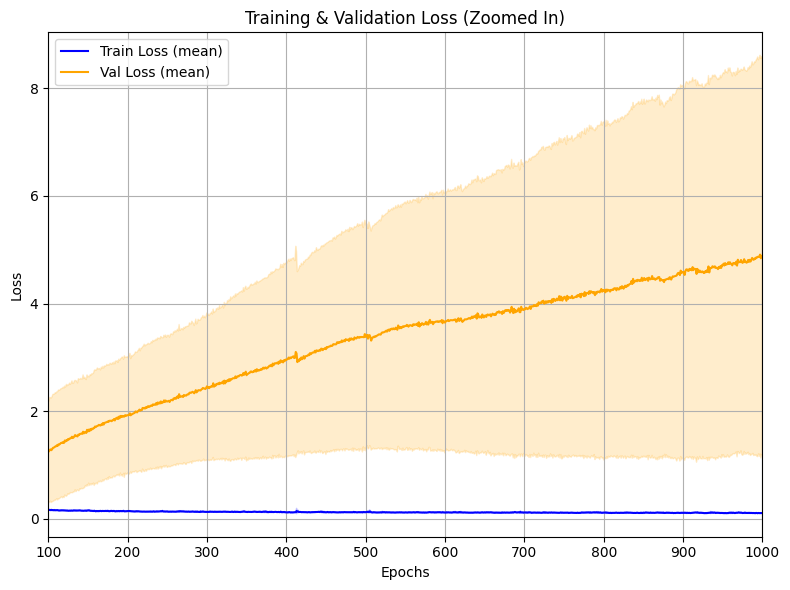

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(epochs, mean_train, label="Train Loss (mean)", color='blue')
plt.fill_between(epochs, mean_train - std_train, mean_train + std_train, alpha=0.2, color='blue')
plt.plot(epochs, mean_val, label="Val Loss (mean)", color='orange')
plt.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange')

# ✅ Zoom into final phase and lower loss values
plt.xlim(100, 1000)       # Focus on last 300 epochs
# plt.ylim(0, 20)            # Focus on low-loss region

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Zoomed In)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


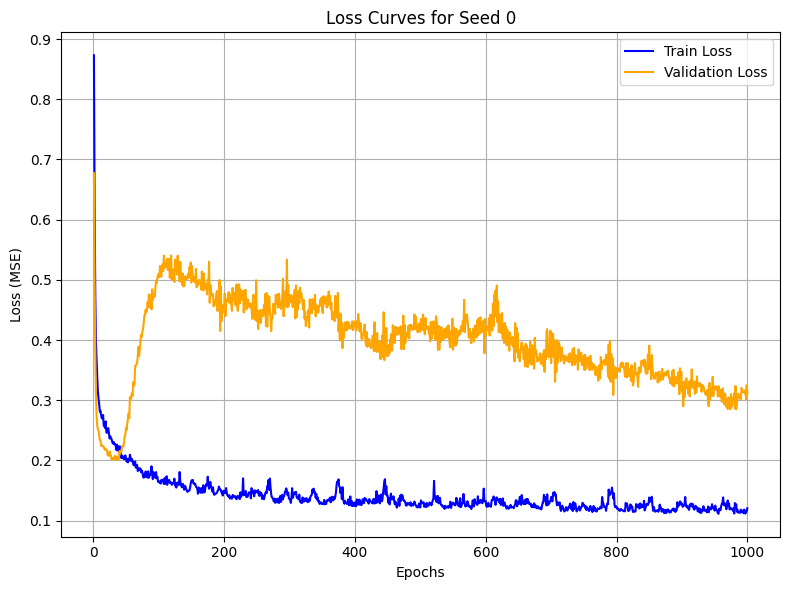

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the loss arrays
seed = 0
train_losses = np.load(f"train_losses_seed_{seed}.npy")
val_losses = np.load(f"val_losses_seed_{seed}.npy")

# Plot
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_losses, label="Train Loss", color="blue")
plt.plot(epochs, val_losses, label="Validation Loss", color="orange")
# plt.xlim(100, 1000)       # Focus on last 300 epochs
# plt.ylim(0, 1)
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title(f"Loss Curves for Seed {seed}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

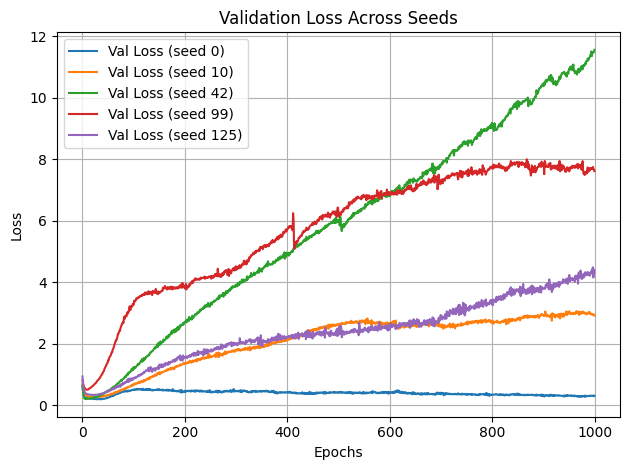

In [ ]:
seeds = [0, 10, 42, 99, 125]
for seed in seeds:
    val_losses = np.load(f"val_losses_seed_{seed}.npy")
    plt.plot(val_losses, label=f"Val Loss (seed {seed})")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Loss Across Seeds")
# plt.xlim(100, 1000)       # Focus on last 300 epochs
# plt.ylim(0, 10)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

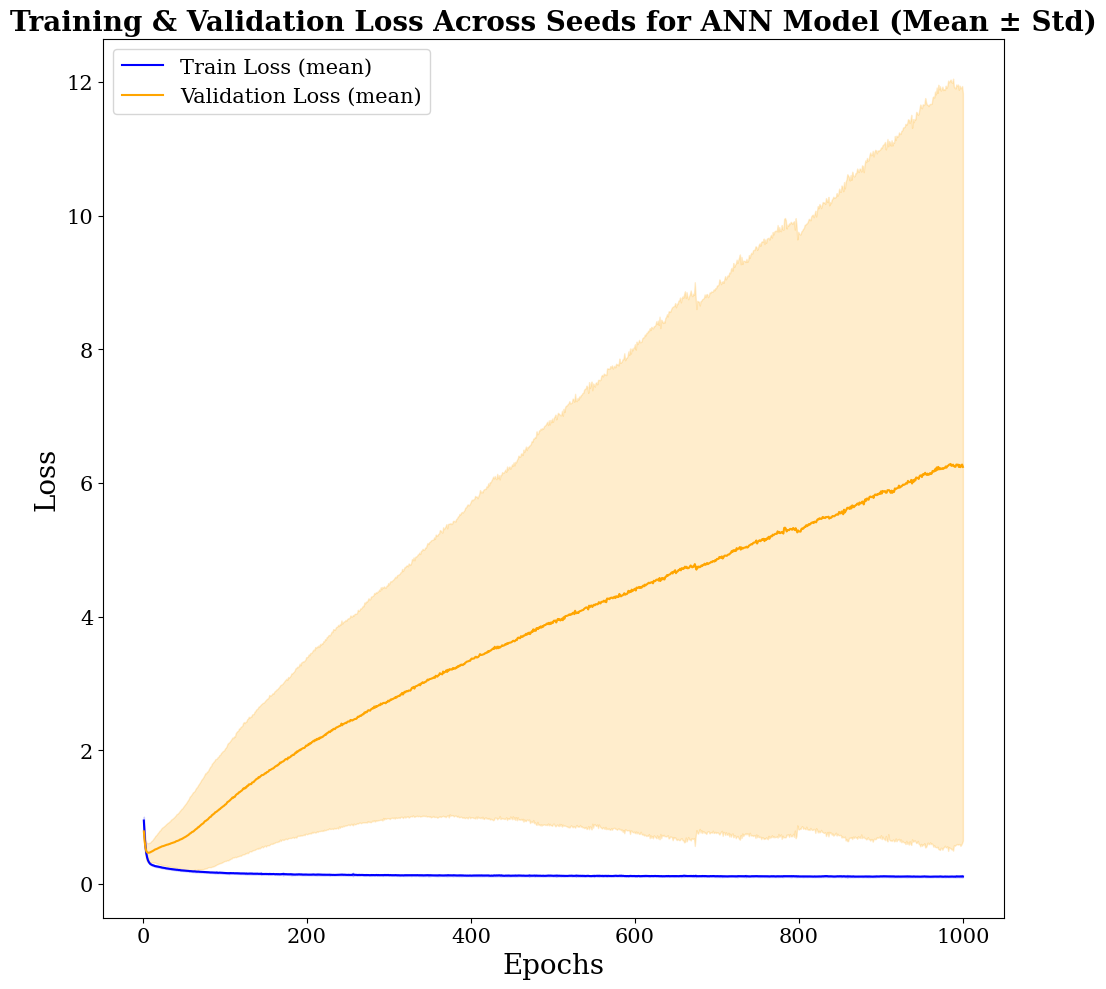

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load all seed loss data
data = np.load("all_seed_losses_DNN.npz", allow_pickle=True)
train_losses_dict = data["train_losses"].item()  # dict: seed -> list of losses
val_losses_dict = data["val_losses"].item()

# Stack and compute mean/std
val_losses_array = np.stack([val_losses_dict[s] for s in sorted(val_losses_dict)])
train_losses_array = np.stack([train_losses_dict[s] for s in sorted(train_losses_dict)])

val_mean = val_losses_array.mean(axis=0)
val_std = val_losses_array.std(axis=0)
train_mean = train_losses_array.mean(axis=0)
train_std = train_losses_array.std(axis=0)

# Plot
epochs = range(1, len(train_mean)+1)
plt.figure(figsize=(10,10))
plt.rcParams['font.family'] = 'serif'  # or 'sans-serif', 'monospace', 'cursive', 'fantasy'
plt.rcParams['font.serif'] = ['DejaVu Serif'] # Specify a particular font within the family
plt.rc('axes', titlesize=20) # Sets the font size for axes titles
plt.rc('axes', labelsize=20) # Sets the font size for axes labels
plt.rc('xtick', labelsize=15) # Sets the font size for x-axis tick labels
plt.rc('ytick', labelsize=15) # Sets the font size for y-axis tick labels
plt.rc('legend', fontsize=15) # Sets the font size for the legend
plt.plot(epochs, train_mean, label="Train Loss (mean)", color="blue")
plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.plot(epochs, val_mean, label="Validation Loss (mean)", color="orange")
plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, alpha=0.2, color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Across Seeds for ANN Model (Mean ± Std)", fontweight='bold')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import re
df = pd.read_csv("composition_stoichiometric_cleaned.csv")
df["Temperature"] = df["Temperature "].apply(lambda x: float(re.sub(r"[^\d.]", "", str(x))))
element_cols = df.columns[2:-1]

In [ ]:
element_cols

Index(['Ag', 'Al', 'As', 'Ba', 'Bi', 'C', 'Ca', 'Cd', 'Ce', 'Cl', 'Co', 'Cu',
       'Dy', 'Eu', 'F', 'Fe', 'G', 'Ga', 'Gd', 'Hf', 'In', 'K', 'La', 'Li',
       'Mg', 'Mm', 'Mn', 'Mo', 'Na', 'Nd', 'Ni', 'O', 'Pb', 'Pd', 'Pr', 'S',
       'Sb', 'Si', 'Sm', 'Sn', 'Sr', 'Te', 'Ti', 'Tl', 'W', 'Y', 'Yb', 'Zn',
       'Zr'],
      dtype='object')

In [ ]:
import random

seeds = random.sample(range(0, 10000), 30)
with open("seeds_used.txt", "w") as f:
    for seed in seeds:
        f.write(f"{seed}\n")

In [ ]:
with open("seeds_used.txt") as f:
    seeds = [int(line.strip()) for line in f]

In [ ]:
seeds

[8763,
 4857,
 5911,
 4401,
 5208,
 386,
 8622,
 7865,
 9936,
 4187,
 7828,
 4673,
 2231,
 7004,
 9477,
 7119,
 1964,
 52,
 8948,
 7788,
 5082,
 5095,
 9844,
 7753,
 3295,
 5966,
 9484,
 9885,
 8846,
 3456]


 Best seed: 5966 with Validation Loss = 0.2828


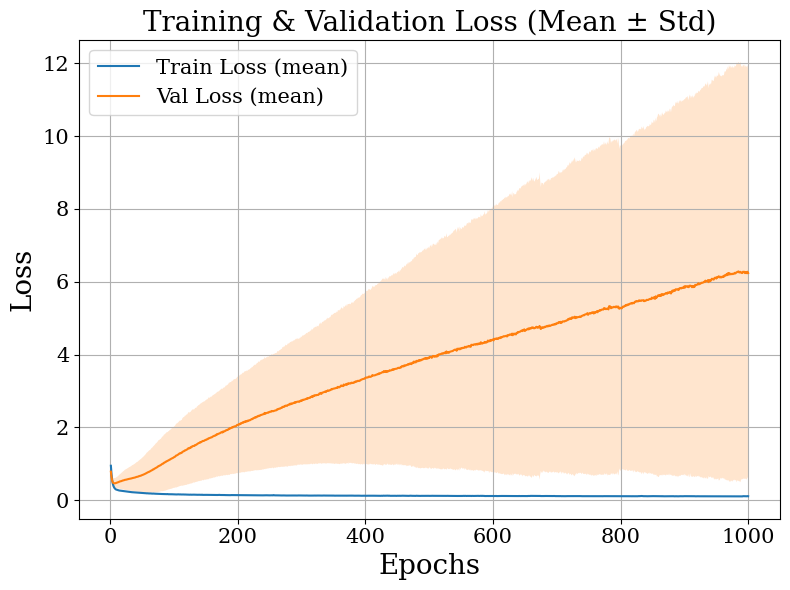

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import random
import re
import pickle
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set reproducibility seed
def set_seed(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

# Load and process dataset
df = pd.read_csv("composition_stoichiometric_cleaned.csv")
df["Temperature"] = df["Temperature "].apply(lambda x: float(re.sub(r"[^\d.]", "", str(x))))
element_cols = df.columns[2:-1]
X = pd.DataFrame({
    "Composition": list(df[element_cols].values),
    "Temperature": df["Temperature"].values
})
y = df["Figure of Merit"].values.reshape(-1, 1)

X_array = np.hstack([
    np.vstack(X["Composition"].values),
    X["Temperature"].values.reshape(-1, 1)
])

# Normalize features and target
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_array)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)
# X_scaled = X_array
# y_scaled = y

# Define DNN model
class FOMRegressor(nn.Module):
  def __init__(self, input_dim):
    super(FOMRegressor, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(input_dim, 128),
        nn.ReLU(),
        nn.Linear(128,1),
    )

  def forward(self, x):
    return self.model(x)

# Prepare dataset once (constant for all seeds)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)
full_dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_train_losses = []
all_val_losses = []
best_seed = None
best_loss = float("inf")
with open("seeds_used.txt") as f:
  seeds = [int(line.strip()) for line in f]
all_models_info = []

all_train_losses_dict = {}
all_val_losses_dict = {}

for seed in seeds:
  set_seed(seed)
  train_dataset, val_dataset = random_split(
      full_dataset, [train_size, val_size],
      generator=torch.Generator().manual_seed(seed)
  )
  train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
  val_loader = DataLoader(val_dataset, batch_size=32)

  model = FOMRegressor(X_tensor.shape[1]).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
  criterion = nn.MSELoss()

  train_losses = []
  val_losses = []

  for epoch in range(1000):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            val_loss += criterion(preds, yb).item()
    val_losses.append(val_loss / len(val_loader))

  # Save losses for this seed
  all_train_losses_dict[seed] = train_losses
  all_val_losses_dict[seed] = val_losses
      # Save all seeds in one compressed file

  final_val_loss = val_losses[-1]
  all_train_losses.append(train_losses)
  all_val_losses.append(val_losses)

  if final_val_loss < best_loss:
      best_loss = final_val_loss
      best_seed = seed
      best_model = model
      best_train_loader = train_loader
      best_val_loader = val_loader
  # Evaluate and record metrics
  model.eval()
  train_preds, train_trues, val_preds, val_trues = [], [], [], []

  with torch.no_grad():
    for xb, yb in train_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()
        train_preds.extend(preds)
        train_trues.extend(yb.cpu().numpy())

    for xb, yb in val_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()
        val_preds.extend(preds)
        val_trues.extend(yb.cpu().numpy())

  # Inverse transform
  train_preds = scaler_y.inverse_transform(train_preds)
  train_trues = scaler_y.inverse_transform(train_trues)
  val_preds = scaler_y.inverse_transform(val_preds)
  val_trues = scaler_y.inverse_transform(val_trues)

  # Compute metrics
  train_mse = mean_squared_error(train_trues, train_preds)
  train_mae = mean_absolute_error(train_trues, train_preds)
  train_r2 = r2_score(train_trues, train_preds)

  val_mse = mean_squared_error(val_trues, val_preds)
  val_mae = mean_absolute_error(val_trues, val_preds)
  val_r2 = r2_score(val_trues, val_preds)

  # Save to list
  all_models_info.append({
      'seed': seed,
      'train_mse': train_mse,
      'train_mae': train_mae,
      'train_r2': train_r2,
      'val_mse': val_mse,
      'val_mae': val_mae,
      'val_r2': val_r2
  })

  # Store true vs predicted values for later analysis
  if 'all_preds_data' not in locals():
      all_preds_data = {}

  all_preds_data[seed] = {
      "train_trues": train_trues,
      "train_preds": train_preds,
      "val_trues": val_trues,
      "val_preds": val_preds,
  }


print(f"\n Best seed: {best_seed} with Validation Loss = {best_loss:.4f}")
np.savez_compressed("all_seed_losses_DNN.npz", train_losses=all_train_losses_dict,
                    val_losses=all_val_losses_dict)

metrics_df = pd.DataFrame(all_models_info)
metrics_df.to_csv("dnn_seed_metrics.csv", index=False)

# --- Save true vs predicted values to pickle file ---
with open("all_seed_true_pred_dnn.pkl", "wb") as f:
  pickle.dump(all_preds_data, f)

# Plot average ± std loss curves
mean_train = np.mean(all_train_losses, axis=0)
std_train = np.std(all_train_losses, axis=0)
mean_val = np.mean(all_val_losses, axis=0)
std_val = np.std(all_val_losses, axis=0)

epochs = range(1, 1001)
plt.figure(figsize=(8,6))
plt.plot(epochs, mean_train, label="Train Loss (mean)")
plt.fill_between(epochs, mean_train - std_train, mean_train + std_train, alpha=0.2)
plt.plot(epochs, mean_val, label="Val Loss (mean)")
plt.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Mean ± Std)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_mean_std_curve_dnn.png")

# True vs Predicted for best seed
best_model.eval()
train_preds, train_trues, val_preds, val_trues = [], [], [], []

with torch.no_grad():
  for xb, yb in best_val_loader:
    xb = xb.to(device)
    output = best_model(xb)
    val_preds.extend(output.cpu().numpy())
    val_trues.extend(yb.numpy())

  for xb, yb in best_train_loader:
    xb = xb.to(device)
    output = best_model(xb)
    train_preds.extend(output.cpu().numpy())
    train_trues.extend(yb.numpy())

# Final plot

# Optional: inverse transform if needed
train_preds = scaler_y.inverse_transform(train_preds)
train_trues = scaler_y.inverse_transform(train_trues)
val_preds = scaler_y.inverse_transform(val_preds)
val_trues = scaler_y.inverse_transform(val_trues)